In [1]:
import IPython
import os
notebook_path = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")
    )
notebook_dir = os.path.dirname(os.path.abspath(notebook_path))
os.chdir(notebook_dir)
os.chdir('../../../')
!pwd

/Users/vipin/BHT - Data Science/CalgoLab/BGR


In [2]:
import sqlite3
import pandas as pd
import ast
import re
import os

db_path = '../data/BGR/sqlite/database_soilnet-study_27-01-26.db'
table = 'predictions'

if os.path.exists(db_path):
    print(f"Database found at {db_path}")
else:
    raise FileNotFoundError(f"Database not found at {db_path}")

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql(f"SELECT * FROM {table}", conn, index_col='id')
    
    df['time_stamp'] = pd.to_datetime(df['time_stamp']) # Convert timestamp to datetime
    
    df['skipped'] = df['skipped'].astype(bool) # Convert skipped to integer
    
    df["image_name"] = df["image_path"].apply(lambda x: os.path.basename(x)) # Extract image name from path
    
    df['depths'] = df['depths'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split depths into list
    df['depths'] = df['depths'].apply(lambda lst: [float(i) if i != '' else None for i in lst]) # Convert depths to float
    df['user_depths'] = df['depths'].apply(lambda lst: [d for d in lst if d is not None]) # Remove None values
    
    df['symbols'] = df['symbols'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split symbols into list
    df['user_symbols'] = df['symbols'].apply(lambda lst: [s.strip().strip("'").strip('"')for s in lst]) # Clean symbols
    
    df['ml_assisted'] = df['ml_assisted'].astype(bool) # Convert ml_assisted to integer

    # Parse ml_depths safely: accept lists or stringified lists
    df['ml_depths'] = df['ml_depths'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and isinstance(x, str) else (x if pd.notnull(x) else []))

    def _parse_ml_symbols(x):
        if pd.isnull(x):
            return []
        if isinstance(x, list):
            return x
        try:
            return ast.literal_eval(x)
        except Exception:
            parts = re.findall(r'\[([^]]+)\]', str(x))
            out = []
            for p in parts:
                items = [s.strip().strip("'\"") for s in p.split(',') if s.strip()]
                out.append(items)
            return out

    df['ml_symbols'] = df['ml_symbols'].apply(_parse_ml_symbols)
    
    df = df[['time_stamp', 'image_idx', 'image_name', 'anonId', 'skipped', 'ml_assisted', 'user_depths', 'user_symbols', 'ml_depths', 'ml_symbols']] # Reorder columns
    
    df = df[df['anonId'] != 'demo_user'] # Remove demo_user entries

df_all = df
df_ml_assisted = df[df['ml_assisted'] == True]
df_non_assisted = df[df['ml_assisted'] == False]
print(f"ML Assisted entries: {len(df_ml_assisted)}, Skipped ratio: {df_ml_assisted['skipped'].mean():.2%}")
display(df_ml_assisted.head())
print(f"Non-ML Assisted entries: {len(df_non_assisted)}, Skipped ratio: {df_non_assisted['skipped'].mean():.2%}")
display(df_non_assisted.head())

Database found at ../data/BGR/sqlite/database_soilnet-study_27-01-26.db
ML Assisted entries: 325, Skipped ratio: 73.85%


,time_stamp,image_idx,image_name,anonId,skipped,ml_assisted,user_depths,user_symbols,ml_depths,ml_symbols
id,,,,,,,,,,
393,2026-01-16 21:49:51.353703,336,NI_0970_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.08874928301030992, 0.47325979687950875, 0.7...","[Ah, Bv, Bv-Cv, Cv]","[0.2853715419769287, 0.556149423122406, 0.8318...","[[Ap, Sw-Ap, Ah, Aep, Axp], [Ah-Bv, Ael-Bv, Al..."
394,2026-01-16 22:01:13.331204,309,MV_0880_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.3806839682839134, 0.8242160948840055]","[Ap, Gro, Gr]","[0.26818302273750305, 0.5338855981826782, 0.80...","[[Ap, Sw-Ap, Ah, Axp, Aep], [Sw-Ah, Ah, Sw-Ap,..."
395,2026-01-16 22:16:49.472948,282,MV_0429_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,[0.3263661471280186],"[Ah, P.]","[0.2663155794143677, 0.5227304697036743, 0.784...","[[Ap, Sw-Ap, Ah, Sw-Ah, Axp], [Ap, Sw-Ap, Sw-A..."
396,2026-01-16 22:22:54.836204,234,HE_3531_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.3882290926846591, 0.621246476606889]","[Ap, Bv, Bv-Cv]","[0.21845737099647522, 0.45969074964523315, 0.7...","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ..."
397,2026-01-16 22:29:41.161534,225,HE_3166_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.22702004855329344, 0.5811495845968063]","[Sw-Ap, P-Sd, Sd-ilC]","[0.2682620584964752, 0.5399075746536255, 0.818...","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ..."


Non-ML Assisted entries: 359, Skipped ratio: 51.81%


,time_stamp,image_idx,image_name,anonId,skipped,ml_assisted,user_depths,user_symbols,ml_depths,ml_symbols
id,,,,,,,,,,
1,2025-11-05 09:52:27.765994,483,RP_3343_Y_2.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.1795454545454546, 0.5909090909090916]","[Ah, Al-Sw, Bt-Sd]",[],[]
5,2025-11-05 14:05:06.900418,316,NI_0439_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.3590909090909091, 0.6545454545454549]","[Ap, Bsh, Bsh]",[],[]
6,2025-11-06 05:38:50.260315,483,RP_3343_Y_2.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.19772727272727272, 0.5681818181818182]","[Ap, Sw, Bv-Sd]",[],[]
7,2025-11-06 05:38:59.609002,316,NI_0439_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,True,False,[],[?],[],[]
8,2025-11-06 05:39:52.854213,147,BY_4531_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.20909090909090908, 0.6181818181818182]","[Ap, Bv, Bv-Cv]",[],[]


Distribution of annotations per image_name (non-ML assisted):


/var/folders/gt/zszlf_dx519294b6bw7dbv0h0000gn/T/ipykernel_90650/2810993100.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_assisted['image_name'] = pd.Categorical(df_non_assisted['image_name'], categories=order, ordered=True)


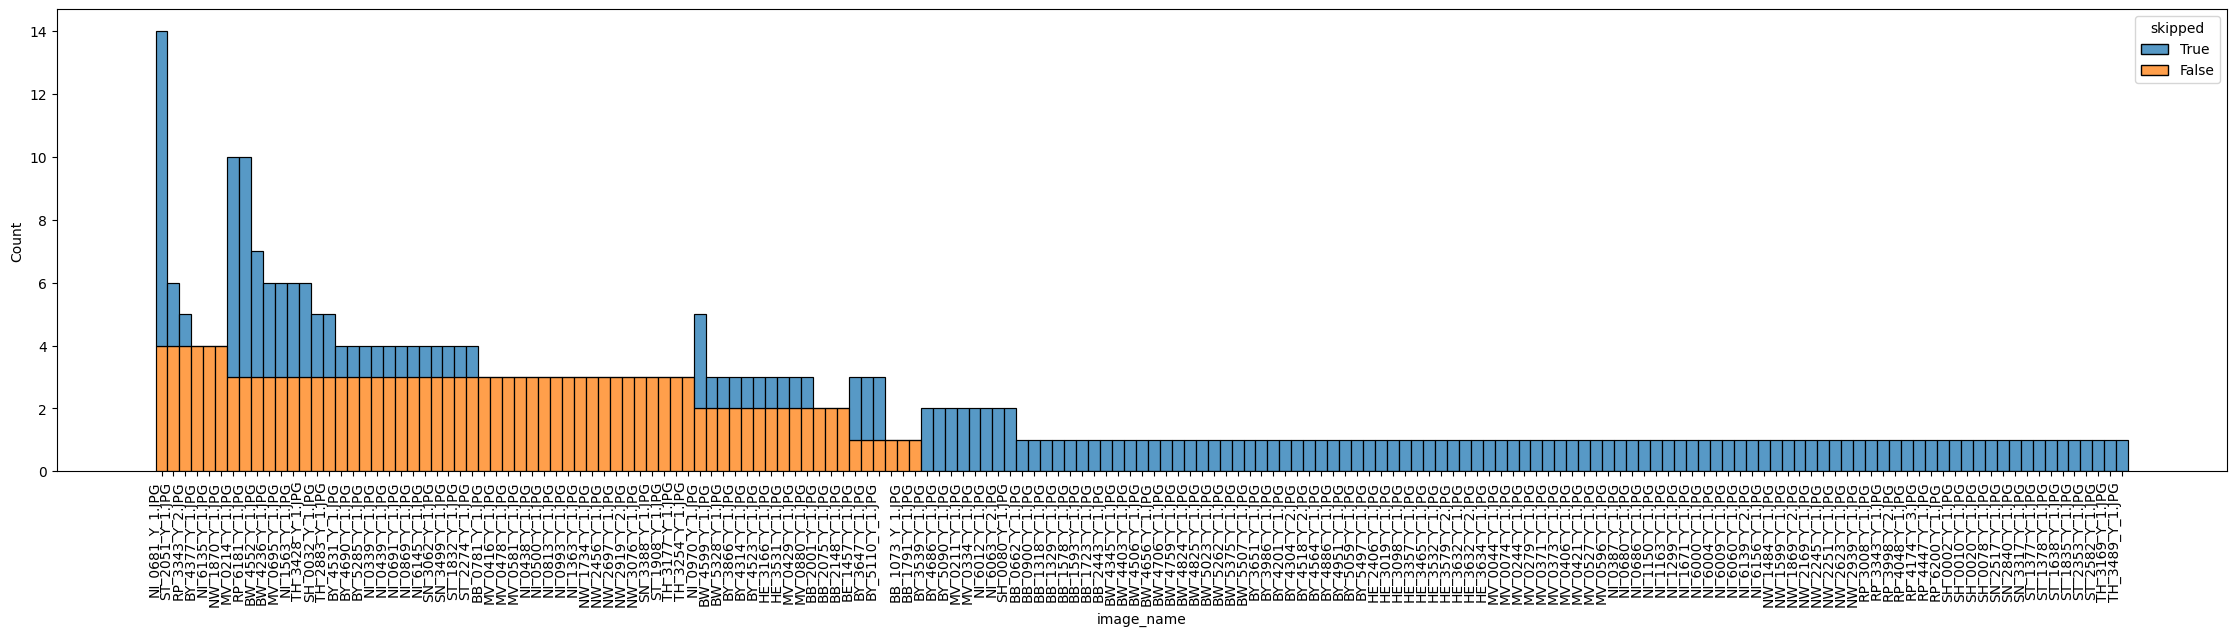

Number of images: 165
Distribution (non-skipped count -> #images):
False
0    101
1      6
2     13
3     39
4      6
Name: count, dtype: int64


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Distribution of annotations per image_name (non-ML assisted):")

plt.figure(figsize=(28, 6))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
order = df_non_assisted.loc[~df_non_assisted['skipped'], 'image_name'].value_counts().sort_values(ascending=False).index.tolist()
# compute counts per image_name for both hue values
counts = df_non_assisted.groupby(['image_name', 'skipped']).size().unstack(fill_value=0)

# ensure columns exist
prim = counts[False] if False in counts.columns else pd.Series(0, index=counts.index)
sec = counts[True] if True in counts.columns else pd.Series(0, index=counts.index)

# sort by primary (non-skipped) descending, then by secondary (skipped) descending
order = sorted(counts.index, key=lambda n: (-int(prim.loc[n]), -int(sec.loc[n])))

# append any remaining names preserving original uniqueness
order += [n for n in df_non_assisted['image_name'].unique() if n not in order]
df_non_assisted['image_name'] = pd.Categorical(df_non_assisted['image_name'], categories=order, ordered=True)
sns.histplot(data=df_non_assisted, x='image_name', hue='skipped', multiple='stack', hue_order=[True, False])
plt.show()

# distribution of number of non-skipped annotations per image_name
dist = prim.value_counts().sort_index()
print("Number of images:", prim.size)
print("Distribution (non-skipped count -> #images):")
print(dist)

Distribution of annotations per image_name (ML assisted):


/var/folders/gt/zszlf_dx519294b6bw7dbv0h0000gn/T/ipykernel_90650/475441154.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_assisted['image_name'] = pd.Categorical(df_ml_assisted['image_name'], categories=order, ordered=True)


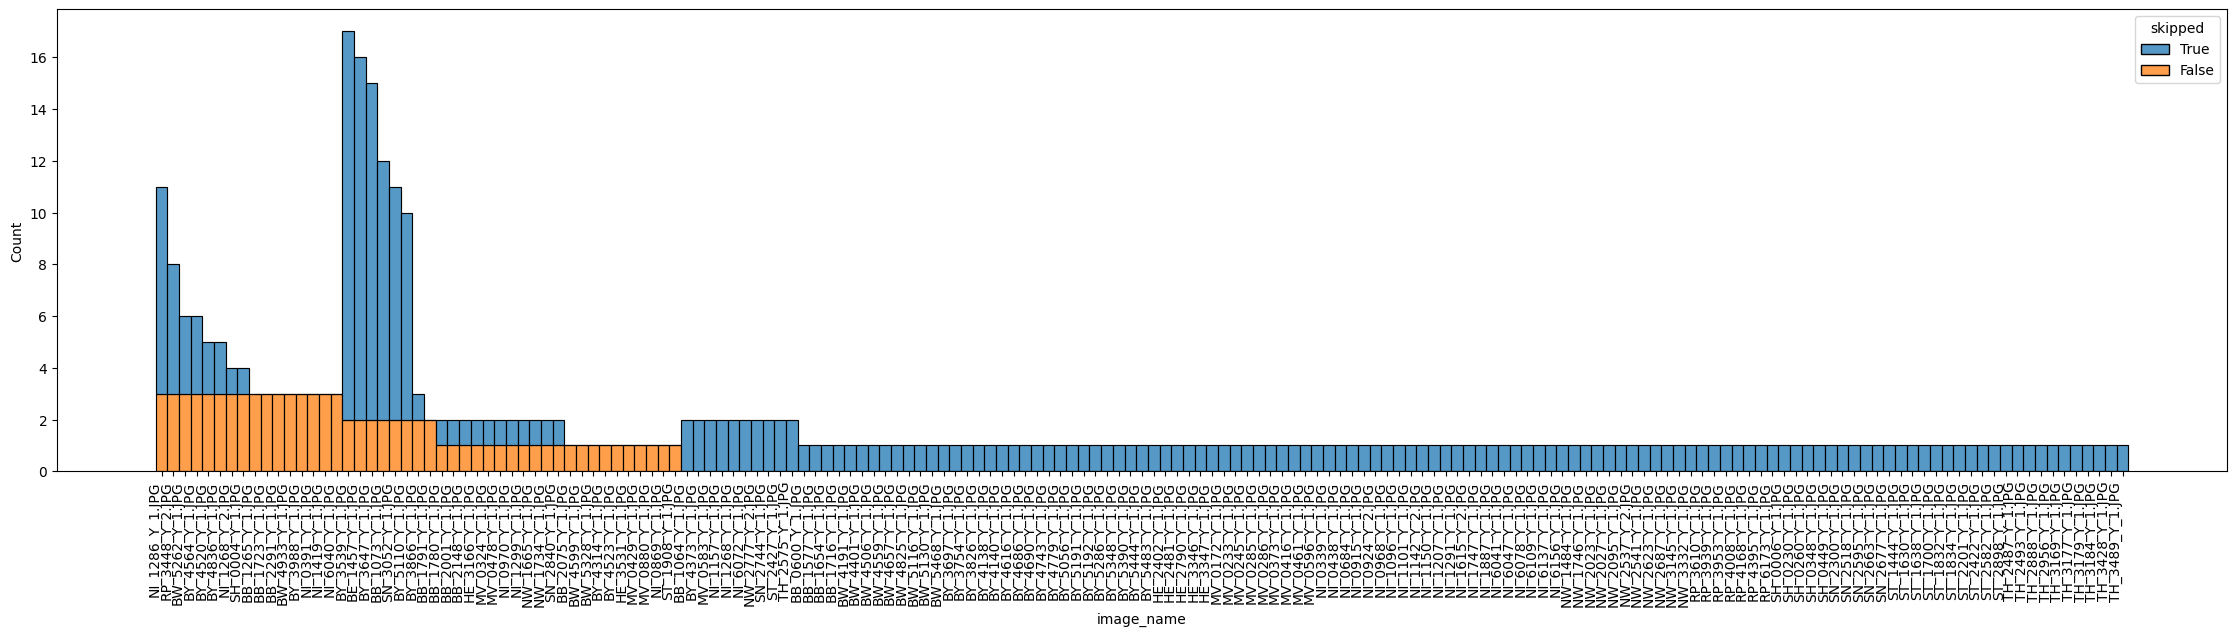

Number of images: 169
Distribution (non-skipped count -> #images):
False
0    124
1     21
2      8
3     16
Name: count, dtype: int64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Distribution of annotations per image_name (ML assisted):")

plt.figure(figsize=(28, 6))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
order = df_ml_assisted.loc[~df_ml_assisted['skipped'], 'image_name'].value_counts().sort_values(ascending=False).index.tolist()
# compute counts per image_name for both hue values
counts = df_ml_assisted.groupby(['image_name', 'skipped']).size().unstack(fill_value=0)

# ensure columns exist
prim = counts[False] if False in counts.columns else pd.Series(0, index=counts.index)
sec = counts[True] if True in counts.columns else pd.Series(0, index=counts.index)

# sort by primary (non-skipped) descending, then by secondary (skipped) descending
order = sorted(counts.index, key=lambda n: (-int(prim.loc[n]), -int(sec.loc[n])))

# append any remaining names preserving original uniqueness
order += [n for n in df_ml_assisted['image_name'].unique() if n not in order]
df_ml_assisted['image_name'] = pd.Categorical(df_ml_assisted['image_name'], categories=order, ordered=True)
sns.histplot(data=df_ml_assisted, x='image_name', hue='skipped', multiple='stack', hue_order=[True, False])
plt.show()

# distribution of number of non-skipped annotations per image_name
dist = prim.value_counts().sort_index()
print("Number of images:", prim.size)
print("Distribution (non-skipped count -> #images):")
print(dist)

In [5]:
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

import sys
sys.path.append('./BGR')

from bgr.soil.modelling.soilnet import SoilNet_LSTM
from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
import bgr.soil.conformal as bgr_conform

IMAGE_PATH_COLUMN = 'file'
DEPTHS_COLUMN = 'Untergrenze'
LABELS_COLUMN = 'Horizontsymbol_relevant'

dataprocessor = HorizonDataProcessor(label_embeddings_path='BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
all_horizon_data = dataprocessor.load_processed_data()
_, _, test_data = dataprocessor.multi_label_stratified_shuffle_split(
    all_horizon_data,
    train_val_test_frac=[0.6, 0.2, 0.2], # Dont change this!
    random_state=2025 # Dont change this!
)

test_data.reset_index(drop=True, inplace=True)

true_data = test_data[[IMAGE_PATH_COLUMN, DEPTHS_COLUMN, LABELS_COLUMN]]
true_data["image_name"] = true_data["file"].apply(lambda x: os.path.basename(x)) # Extract image name from path
true_data["true_depths"] = true_data[DEPTHS_COLUMN].apply(lambda x: x[:-1]) # Remove last depth (stop_token = 1.0)
true_data["true_symbols"] = true_data[LABELS_COLUMN].apply(lambda x: [dataprocessor.embeddings_dict["ind2label"][ind] for ind in x])

true_data = true_data[["image_name",  "true_depths", "true_symbols"]]

true_data.head()

,image_name,true_depths,true_symbols
0,BB_0600_Y_1.JPG,"[0.29, 0.4, 0.54, 0.6, 0.8]","[Ap, Sd-ilC, Sd-ilC, Sd, Sd-lC, Sd]"
1,BB_0659_Y_1.JPG,"[0.3, 0.47, 0.73]","[Ap, Ael, Ael-Bt, Bt]"
2,BB_0662_Y_1.JPG,"[0.3, 0.46, 0.73]","[Acxh, Acxh, elCc, elC]"
3,BB_0720_Y_1.JPG,"[0.3, 0.54]","[Ap, elC, elC]"
4,BB_0721_Y_1.JPG,"[0.34, 0.54, 0.67]","[Axp, Axh, Axh, Sd-lC]"


In [6]:
df_merged = pd.merge(df_all, true_data, on='image_name')
df_merged.head()

,time_stamp,image_idx,image_name,anonId,skipped,ml_assisted,user_depths,user_symbols,ml_depths,ml_symbols,true_depths,true_symbols
0,2025-11-05 09:52:27.765994,483,RP_3343_Y_2.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.1795454545454546, 0.5909090909090916]","[Ah, Al-Sw, Bt-Sd]",[],[],"[0.28, 0.49, 0.73]","[Ap, Bv-Sw, Sd, ilC-Sd]"
1,2025-11-05 14:05:06.900418,316,NI_0439_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.3590909090909091, 0.6545454545454549]","[Ap, Bsh, Bsh]",[],[],"[0.4, 0.5, 0.7]","[Ap, Bh, Bv, Go]"
2,2025-11-06 05:38:50.260315,483,RP_3343_Y_2.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.19772727272727272, 0.5681818181818182]","[Ap, Sw, Bv-Sd]",[],[],"[0.28, 0.49, 0.73]","[Ap, Bv-Sw, Sd, ilC-Sd]"
3,2025-11-06 05:38:59.609002,316,NI_0439_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,True,False,[],[?],[],[],"[0.4, 0.5, 0.7]","[Ap, Bh, Bv, Go]"
4,2025-11-06 05:39:52.854213,147,BY_4531_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.20909090909090908, 0.6181818181818182]","[Ap, Bv, Bv-Cv]",[],[],"[0.12, 0.34]","[Ap, Ap, M.]"


## Pad and truncate the user/ml depths/symbols lists to match the true depths/symbols lengths

In [7]:
df = df_merged.copy()

for row in df.iterrows():
    row = row[1]
    true_depths = row['true_depths']
    true_symbols = row['true_symbols']
    
    # Pad/truncate user_depths
    user_depths = row['user_depths']
    while len(user_depths) < len(true_depths):
        user_depths.append(1.0)  # Padding with stop_token
    user_depths = user_depths[:len(true_depths)]
    
    # Pad/truncate user_symbols
    user_symbols = row['user_symbols']
    while len(user_symbols) < len(true_symbols):
        user_symbols.append('-1')  # Padding with -1 symbol
    user_symbols = user_symbols[:len(true_symbols)]
    
    if row['ml_assisted']:    
        # Pad/truncate ml_depths
        ml_depths = row['ml_depths']
        while len(ml_depths) < len(true_depths):
            ml_depths.append(1.0)  # Padding with stop_token
        ml_depths = ml_depths[:len(true_depths)]
        
        # Pad/truncate ml_symbols
        ml_symbols = row['ml_symbols']
        while len(ml_symbols) < len(true_symbols):
            ml_symbols.append(['-1', '-1', '-1', '-1', '-1'])  # Padding with -1 symbol
        ml_symbols = ml_symbols[:len(true_symbols)]

    df.at[row.name, 'user_depths'] = user_depths
    df.at[row.name, 'user_symbols'] = user_symbols
    if row['ml_assisted']:
        df.at[row.name, 'ml_depths'] = ml_depths
        df.at[row.name, 'ml_symbols'] = ml_symbols

display(df[(df["skipped"] == False) & (df["ml_assisted"] == False)].head())
display(df[(df["skipped"] == False) & (df["ml_assisted"] == True)].head())

,time_stamp,image_idx,image_name,anonId,skipped,ml_assisted,user_depths,user_symbols,ml_depths,ml_symbols,true_depths,true_symbols
0,2025-11-05 09:52:27.765994,483,RP_3343_Y_2.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.1795454545454546, 0.5909090909090916, 1.0]","[Ah, Al-Sw, Bt-Sd, -1]",[],[],"[0.28, 0.49, 0.73]","[Ap, Bv-Sw, Sd, ilC-Sd]"
1,2025-11-05 14:05:06.900418,316,NI_0439_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,False,"[0.3590909090909091, 0.6545454545454549, 1.0]","[Ap, Bsh, Bsh, -1]",[],[],"[0.4, 0.5, 0.7]","[Ap, Bh, Bv, Go]"
2,2025-11-06 05:38:50.260315,483,RP_3343_Y_2.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.19772727272727272, 0.5681818181818182, 1.0]","[Ap, Sw, Bv-Sd, -1]",[],[],"[0.28, 0.49, 0.73]","[Ap, Bv-Sw, Sd, ilC-Sd]"
4,2025-11-06 05:39:52.854213,147,BY_4531_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,False,"[0.20909090909090908, 0.6181818181818182]","[Ap, Bv, Bv-Cv]",[],[],"[0.12, 0.34]","[Ap, Ap, M.]"
8,2025-11-06 13:27:55.034819,316,NI_0439_Y_1.JPG,aa4bc528-5f3b-4d19-9b10-9f6d00356edb,False,False,"[0.38181818181818183, 0.6672727411443536, 1.0]","[Ah, Bv, Cv, -1]",[],[],"[0.4, 0.5, 0.7]","[Ap, Bh, Bv, Go]"


,time_stamp,image_idx,image_name,anonId,skipped,ml_assisted,user_depths,user_symbols,ml_depths,ml_symbols,true_depths,true_symbols
358,2026-01-16 21:49:51.353703,336,NI_0970_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.08874928301030992, 0.47325979687950875, 0.7...","[Ah, Bv, Bv-Cv, Cv]","[0.2853715419769287, 0.556149423122406, 0.8318...","[[Ap, Sw-Ap, Ah, Aep, Axp], [Ah-Bv, Ael-Bv, Al...","[0.33, 0.5, 0.7]","[Ap, Bsh, ilC, ilC]"
359,2026-01-16 22:01:13.331204,309,MV_0880_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.3806839682839134, 0.8242160948840055, 1.0, ...","[Ap, Gro, Gr, -1, -1, -1]","[0.26818302273750305, 0.5338855981826782, 0.80...","[[Ap, Sw-Ap, Ah, Axp, Aep], [Sw-Ah, Ah, Sw-Ap,...","[0.14, 0.34, 0.52, 0.67, 0.96]","[Ap, Ap, Go, Gro, Gor, Gr]"
360,2026-01-16 22:16:49.472948,282,MV_0429_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.3263661471280186, 1.0, 1.0]","[Ah, P., -1, -1]","[0.2663155794143677, 0.5227304697036743, 0.784...","[[Ap, Sw-Ap, Ah, Sw-Ah, Axp], [Ap, Sw-Ap, Sw-A...","[0.33, 0.53, 0.67]","[Ap, Al-Sw, Bt-Sd, Sw]"
361,2026-01-16 22:22:54.836204,234,HE_3531_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.3882290926846591, 0.621246476606889]","[Ap, Bv, Bv-Cv]","[0.21845737099647522, 0.45969074964523315]","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ...","[0.27, 0.53]","[Ap, Cv-Bv, mCv]"
362,2026-01-16 22:29:41.161534,225,HE_3166_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,True,"[0.22702004855329344, 0.5811495845968063, 1.0]","[Sw-Ap, P-Sd, Sd-ilC, -1]","[0.2682620584964752, 0.5399075746536255, 0.818...","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ...","[0.3, 0.5, 0.7]","[Ap, Bv, elC, elC]"


## Compute Metrics
### IoU, Accuracy and Main Symbol Accuracy

In [8]:
def _prep_depths(depths):
    """Clean, sort, and add 0/1 boundaries."""
    if depths is None:
        depths = []
    cleaned = [float(d) for d in depths if d is not None]
    cleaned = [d for d in cleaned if 0.0 <= d <= 1.0]
    cleaned.sort()
    if not cleaned or cleaned[-1] < 1.0:
        cleaned.append(1.0)        # stop token / bottom
    return [0.0] + cleaned         # top

def depth_iou(pred_depths, true_depths, return_iou_list : bool = False):
    p = _prep_depths(pred_depths)
    t = _prep_depths(true_depths)
    n_segments = min(len(p), len(t)) - 1
    if n_segments <= 0:
        return 0.0

    ious = []
    for i in range(n_segments):
        pa, pb = p[i], p[i+1]
        ta, tb = t[i], t[i+1]
        inter = max(0.0, min(pb, tb) - max(pa, ta))
        union = max(pb, tb) - min(pa, ta)
        ious.append(inter / union if union > 0 else 0.0)

    if return_iou_list:
        return ious
    else:
        return sum(ious) / n_segments

def get_main_symbol(s):
    label = str(s).strip().strip("'\"")
    caps = re.findall(r"[A-Z]", label)
    return caps[-1] if caps else (label[0] if label else "")

def compute_user_metrics(df):
    user_running_ious = {}
    user_running_accuracies = {}
    user_running_main_accuracies = {}
    user_counts = {}

    for row in df.iterrows():
        row = row[1]
    
        user_id = row['anonId']
        if user_id not in user_counts:
            user_counts[user_id] = 1
        else:
            user_counts[user_id] += 1    
    
        user_depths = row['user_depths']
        true_depths = row['true_depths']
    
        user_ious = depth_iou(user_depths, true_depths, return_iou_list=True)
    
        if user_id not in user_running_ious:
            user_running_ious[user_id] = user_ious
        else:
            user_running_ious[user_id].extend(user_ious)
    
        user_symbols = row['user_symbols']
        true_symbols = row['true_symbols']
    
        if user_id not in user_running_accuracies:
            user_running_accuracies[user_id] = [s1 == s2 for s1, s2 in zip(user_symbols, true_symbols)]
        else:
            user_running_accuracies[user_id].extend([s1 == s2 for s1, s2 in zip(user_symbols, true_symbols)])
    
        user_main_symbols = [get_main_symbol(s) for s in user_symbols]
        true_main_symbols = [get_main_symbol(s) for s in true_symbols]
    
        if user_id not in user_running_main_accuracies:
            user_running_main_accuracies[user_id] = [s1 == s2 for s1, s2 in zip(user_main_symbols, true_main_symbols)]
        else:
            user_running_main_accuracies[user_id].extend([s1 == s2 for s1, s2 in zip(user_main_symbols, true_main_symbols)])

    user_avg_ious_non_assisted = {user: np.mean(ious) for user, ious in user_running_ious.items()}
    user_avg_accuracies_non_assisted = {user: np.mean(accs) for user, accs in user_running_accuracies.items()}
    user_avg_main_accuracies_non_assisted = {user: np.mean(accs) for user, accs in user_running_main_accuracies.items()}

    user_metrics_non_assisted = pd.DataFrame({
        'user_id': list(user_avg_ious_non_assisted.keys()),
        'avg_iou': list(user_avg_ious_non_assisted.values()),
        'avg_accuracy': list(user_avg_accuracies_non_assisted.values()),
        'avg_main_accuracy': list(user_avg_main_accuracies_non_assisted.values()),
        'num_annotations': [user_counts[user] for user in user_counts.keys()]
    }).sort_values(by='num_annotations', ascending=False)
    
    return user_metrics_non_assisted

In [9]:
df_non_assisted = df[(df["skipped"] == False) & (df["ml_assisted"] == False)]

user_metrics_non_assisted = compute_user_metrics(df_non_assisted)
print("User Metrics (Non-ML Assisted):")
display(user_metrics_non_assisted)

User Metrics (Non-ML Assisted):


,user_id,avg_iou,avg_accuracy,avg_main_accuracy,num_annotations
13,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,0.330192,0.187500,0.338542,47
16,70d8591c-b52a-4081-9efb-732d6632f592,0.513682,0.242424,0.515152,27
21,7671f031-bf25-4e3d-a32f-b9eac573b10a,0.396296,0.230000,0.400000,24
3,89138847-ac09-4a58-9912-b308d7ac5f7f,0.515283,0.188406,0.463768,18
5,5cfcc301-8fda-40ee-967e-7655283c8cd4,0.226691,0.175000,0.425000,9
20,3369cec8-47c2-4421-ac66-33a034dc4b67,0.460254,0.281250,0.500000,8
12,52f0815d-26b9-4973-8074-97f587625f8a,0.068261,0.000000,0.066667,7
4,d595d4f6-a471-45d8-b939-414bb0184e8b,0.572805,0.333333,0.333333,5
8,729f9836-70b7-4119-b4b7-f0d9d3e3702b,0.323721,0.263158,0.421053,5
2,aa4bc528-5f3b-4d19-9b10-9f6d00356edb,0.663037,0.250000,0.500000,4


In [10]:
df_assisted = df[(df["skipped"] == False) & (df["ml_assisted"] == True)]

user_metrics_assisted = compute_user_metrics(df_assisted)
print("User Metrics (ML Assisted):")
display(user_metrics_assisted)

User Metrics (ML Assisted):


,user_id,avg_iou,avg_accuracy,avg_main_accuracy,num_annotations
9,e66e6324-1a6c-4c89-9b8e-acc136f6999a,0.571645,0.274510,0.607843,13
3,89138847-ac09-4a58-9912-b308d7ac5f7f,0.483954,0.288462,0.365385,11
0,5457af96-fa4b-4780-b362-af71266b4dbf,0.363211,0.113636,0.500000,10
10,bedaf05b-d9c4-4566-8b5c-832269dd9a12,0.470845,0.190476,0.452381,10
7,3e4d74e9-95cd-48f5-9ca1-9b6dc87e8341,0.438360,0.333333,0.487179,9
8,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,0.500440,0.435897,0.641026,9
11,d032e40f-7807-4881-9455-2e7243ff4bcb,0.350984,0.138889,0.444444,9
6,3bc929ee-1057-4f7e-84ce-b7f4b918c1ab,0.428144,0.264706,0.558824,8
4,470da56a-cc8a-46e7-a12e-ea9c83fe78eb,0.410862,0.200000,0.466667,3
1,3613e9e3-2e30-454a-b1ad-adfbd0dcd683,0.160506,0.333333,0.500000,1


### Compute Model Metrics (IoU, Acc, Main-Acc)

In [11]:
model_running_ious = []
model_running_accuracies = []
model_running_main_accuracies = []

for row in df.iterrows():
    row = row[1]
    
    if len(row['ml_depths']) > 0:
        ml_depths = row['ml_depths']
        true_depths = row['true_depths']
        
        model_ious = depth_iou(ml_depths, true_depths, return_iou_list=True)
        model_running_ious.extend(model_ious)
        
        ml_symbols = [symbols[0] for symbols in row['ml_symbols']] # Retrieve Top-1 Prediction
        true_symbols = row['true_symbols']
        
        model_running_accuracies.extend([s1 == s2 for s1, s2 in zip(ml_symbols, true_symbols)])
        
        ml_main_symbols = [get_main_symbol(s) for s in ml_symbols]
        true_main_symbols = [get_main_symbol(s) for s in true_symbols]
        
        model_running_main_accuracies.extend([s1 == s2 for s1, s2 in zip(ml_main_symbols, true_main_symbols)])

model_ious = np.mean(model_running_ious) * 100
model_full_acc = np.mean(model_running_accuracies)  * 100
model_main_acc = np.mean(model_running_main_accuracies) * 100

### Inter-User Agreement and User-Model Agreement (Top-5)

In [12]:
# Get image names with at least 3 annotations
image_annotation_counts = df_non_assisted['image_name'].value_counts()
images_with_min_annotations = image_annotation_counts[image_annotation_counts >= 3].index.unique().tolist()

inter_user_agreements_non_assisted = []
inter_user_main_agreements_non_assisted = []

for image_name in images_with_min_annotations:
    annotations = df_non_assisted[df_non_assisted['image_name'] == image_name]
    
    user_symbols = annotations['user_symbols']
    
    for i in range(len(user_symbols.iloc[0])): # foreach horizon
        symbols_at_depth = [user_symbols.iloc[j][i] for j in range(len(user_symbols))] # foreach user at this horizon
        main_symbols_at_depth = [get_main_symbol(s) for s in symbols_at_depth]
        
        number_of_users = len(symbols_at_depth)
        unique_symbols = set(symbols_at_depth)
        main_unique_symbols = set(main_symbols_at_depth)
        
        # Compute inter-user agreement
        agreement = (number_of_users - len(unique_symbols)) / (number_of_users - 1)
        inter_user_agreements_non_assisted.append(agreement)
        
        # Compute inter-user main symbol agreement
        main_agreement = (number_of_users - len(main_unique_symbols)) / (number_of_users - 1)
        inter_user_main_agreements_non_assisted.append(main_agreement)

avg_inter_user_agreement_non_assisted = np.mean(inter_user_agreements_non_assisted)
avg_inter_user_main_agreement_non_assisted = np.mean(inter_user_main_agreements_non_assisted)
print(f"Average Inter-User Agreement (Non-ML Assisted): {avg_inter_user_agreement_non_assisted:.4f}")
print(f"Average Inter-User Main Symbol Agreement (Non-ML Assisted): {avg_inter_user_main_agreement_non_assisted:.4f}")

Average Inter-User Agreement (Non-ML Assisted): 0.3686
Average Inter-User Main Symbol Agreement (Non-ML Assisted): 0.5843


In [13]:
# Get image names with at least 3 annotations
image_annotation_counts = df_assisted['image_name'].value_counts()
images_with_min_annotations = image_annotation_counts[image_annotation_counts >= 3].index.unique().tolist()

inter_user_agreements_assisted = []
inter_user_main_agreements_assisted = []
user_model_agreements_assisted = []
user_model_main_agreements_assisted = []
user_model_agreements_top5_assisted = []
user_model_main_agreements_top5_assisted = []

for image_name in images_with_min_annotations:
    annotations = df_assisted[df_assisted['image_name'] == image_name]
    
    user_symbols = annotations['user_symbols']
    ml_symbols = annotations['ml_symbols']
    
    for i in range(len(user_symbols.iloc[0])): # foreach horizon
        symbols_at_depth = [user_symbols.iloc[j][i] for j in range(len(user_symbols))] # foreach user at this horizon
        main_symbols_at_depth = [get_main_symbol(s) for s in symbols_at_depth]
        
        number_of_users = len(symbols_at_depth)
        unique_symbols = set(symbols_at_depth)
        main_unique_symbols = set(main_symbols_at_depth)
        
        # Compute inter-user agreement
        agreement = (number_of_users - len(unique_symbols)) / (number_of_users - 1)
        inter_user_agreements_assisted.append(agreement)
        
        # Compute inter-user main symbol agreement
        main_agreement = (number_of_users - len(main_unique_symbols)) / (number_of_users - 1)
        inter_user_main_agreements_assisted.append(main_agreement)
        
        # Get top 5 ML symbols at this depth
        top5_ml_symbols_at_depth = [ml_symbols.iloc[j][i] for j in range(len(ml_symbols))]
        # Convert each user's top-5 list to main symbols
        top5_ml_main_symbols_at_depth = [[get_main_symbol(s) for s in top5_symbols] for top5_symbols in top5_ml_symbols_at_depth]
        
        # Compute user-model agreement (compare user symbol to first ML suggestion per user)
        model_agreement = sum([s1 == s2 for s1, s2 in zip(symbols_at_depth, top5_ml_symbols_at_depth[0])]) / number_of_users
        user_model_agreements_assisted.append(model_agreement)
        
        # Compute user-model main symbol agreement (compare main symbols)
        model_main_agreement = sum([s1 == s2 for s1, s2 in zip(main_symbols_at_depth, top5_ml_main_symbols_at_depth[0])]) / number_of_users
        user_model_main_agreements_assisted.append(model_main_agreement)
        
        # Compute user-model top 5 symbol agreement
        model_top5_agreement = sum([s1 in s2 for s1, s2 in zip(symbols_at_depth, top5_ml_symbols_at_depth)]) / number_of_users
        user_model_agreements_top5_assisted.append(model_top5_agreement)
        
        # Compute user-model main symbol top 5 agreement
        model_main_top5_agreement = sum([s1 in s2 for s1, s2 in zip(main_symbols_at_depth, top5_ml_main_symbols_at_depth)]) / number_of_users
        user_model_main_agreements_top5_assisted.append(model_main_top5_agreement)

avg_inter_user_agreement_assisted = np.mean(inter_user_agreements_assisted)
avg_inter_user_main_agreement_assisted = np.mean(inter_user_main_agreements_assisted)
avg_user_model_agreement_assisted = np.mean(user_model_agreements_assisted)
avg_user_model_main_agreement_assisted = np.mean(user_model_main_agreements_assisted)
avg_user_model_top5_agreement_assisted = np.mean(user_model_agreements_top5_assisted)
avg_user_model_main_top5_agreement_assisted = np.mean(user_model_main_agreements_top5_assisted)

print(f"Average Inter-User Agreement (ML Assisted): {avg_inter_user_agreement_assisted:.4f}")
print(f"Average Inter-User Main Symbol Agreement (ML Assisted): {avg_inter_user_main_agreement_assisted:.4f}")
print(f"Average User-Model Agreement (ML Assisted): {avg_user_model_agreement_assisted:.4f}")
print(f"Average User-Model Main Symbol Agreement (ML Assisted): {avg_user_model_main_agreement_assisted:.4f}")
print(f"Average User-Model Top 5 Symbol Agreement (ML Assisted): {avg_user_model_top5_agreement_assisted:.4f}")
print(f"Average User-Model Main Symbol Top 5 Agreement (ML Assisted): {avg_user_model_main_top5_agreement_assisted:.4f}")

Average Inter-User Agreement (ML Assisted): 0.4485
Average Inter-User Main Symbol Agreement (ML Assisted): 0.7132
Average User-Model Agreement (ML Assisted): 0.1863
Average User-Model Main Symbol Agreement (ML Assisted): 0.5735
Average User-Model Top 5 Symbol Agreement (ML Assisted): 0.5147
Average User-Model Main Symbol Top 5 Agreement (ML Assisted): 0.6569


## Plotting

In [70]:
# Plot user metrics (assisted vs non-assisted) and compare to model
# - Use only users with >8 annotations for error bars
# - Optional weighting by annotation count via `weight_by_count` flag
import matplotlib.pyplot as plt
import numpy as np

def plot_statistics(weight_by_count: bool, export_path: str = None):
    plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
    
    def _weighted_stats(vals, counts, weight_flag):
        vals = np.asarray(vals, dtype=float)
        counts = np.asarray(counts, dtype=float)
        n = len(vals)
        if n == 0:
            return np.nan, 0.0
        if not weight_flag:
            mean = np.mean(vals)
            sem = np.std(vals, ddof=1) / np.sqrt(n) if n > 1 else 0.0
            return mean, sem

        # Weighted mean and effective sample size for SEM
        w = counts
        w_sum = w.sum()
        if w_sum == 0:
            return np.mean(vals), 0.0
        w_norm = w / w_sum
        mean = np.sum(w_norm * vals)
        weighted_var = np.sum(w_norm * (vals - mean) ** 2)
        neff = (w_sum ** 2) / np.sum(w ** 2) if np.sum(w ** 2) > 0 else n
        sem = np.sqrt(weighted_var) / np.sqrt(neff) if neff > 1 else 0.0
        return mean, sem

    def _get_stats(user_metrics_df, col):
        # df = user_metrics_df[user_metrics_df['num_annotations'] > 8]
        df = user_metrics_df
        if df.empty:
            return np.nan, 0.0, 0
        vals = df[col].values * 100.0  # convert to percent
        counts = df['num_annotations'].values
        mean, sem = _weighted_stats(vals, counts, weight_by_count)
        return mean, sem, len(df)

    # gather stats for IoU, Accuracy, Main Accuracy
    iou_non_mean, iou_non_sem, n_non = _get_stats(user_metrics_non_assisted, 'avg_iou')
    iou_ass_mean, iou_ass_sem, n_ass = _get_stats(user_metrics_assisted, 'avg_iou')

    acc_non_mean, acc_non_sem, _ = _get_stats(user_metrics_non_assisted, 'avg_accuracy')
    acc_ass_mean, acc_ass_sem, _ = _get_stats(user_metrics_assisted, 'avg_accuracy')

    main_non_mean, main_non_sem, _ = _get_stats(user_metrics_non_assisted, 'avg_main_accuracy')
    main_ass_mean, main_ass_sem, _ = _get_stats(user_metrics_assisted, 'avg_main_accuracy')

    # Prepare plotting arrays
    metrics = ['IoU', 'Accuracy', 'Main Symbol Accuracy']
    non_means = [iou_non_mean, acc_non_mean, main_non_mean]
    ass_means = [iou_ass_mean, acc_ass_mean, main_ass_mean]
    non_sems = [iou_non_sem, acc_non_sem, main_non_sem]
    ass_sems = [iou_ass_sem, acc_ass_sem, main_ass_sem]
    model_vals = [model_ious, model_full_acc, model_main_acc]

    # Plot
    x = np.arange(len(metrics))
    width = 0.25
    small_font_size=20
    big_font_size=25
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width, non_means, width, yerr=non_sems, label=f'Users (non-assisted, n={n_non})', color='C0', capsize=6)
    ax.bar(x, ass_means, width, yerr=ass_sems, label=f'Users (assisted, n={n_ass})', color='C1', capsize=6)
    ax.bar(x + width, model_vals, width, label='Model', color='C2')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 100)
    ax.set_ylabel('(\%)', fontsize=small_font_size)
    ax.set_title('User vs Model Metrics', fontsize=big_font_size)
    ax.legend(fontsize=small_font_size)
    
    # fontsize of ticklabels
    ax.tick_params(axis='both', labelsize=small_font_size)

    # Annotate exact values on bars
    for i in range(len(metrics)):
        if not np.isnan(non_means[i]):
            ax.text(i - width, non_means[i] + non_sems[i] + 2, f'{non_means[i]:.2f}', ha='center', fontsize=small_font_size)
        if not np.isnan(ass_means[i]):
            ax.text(i, ass_means[i] + ass_sems[i] + 2, f'{ass_means[i]:.2f}', ha='center', fontsize=small_font_size)
        ax.text(i + width, model_vals[i] + 2, f'{model_vals[i]:.2f}', ha='center', fontsize=small_font_size)

    plt.tight_layout()
    plt.show()
    
    if export_path:
        fig.savefig(export_path)
        print("Saved to", export_path)

    # Print summary
    print(f'Users considered: non-assisted={n_non}, assisted={n_ass}')
    print('Weight by annotation count:', weight_by_count)

    # Comments:
    # - Error bars show variability across users (SEM). If you prefer SD, change _weighted_stats accordingly.
    # - When weight_by_count=True, each user's contribution is weighted by their annotation count; SEM computed using effective sample size.
    # - Model values are single aggregated metrics and thus plotted without error bars.
    # - If you want per-image aggregation instead of per-user, replace grouping in compute_user_metrics accordingly.

In [66]:
!pwd

/Users/vipin/BHT - Data Science/CalgoLab/BGR


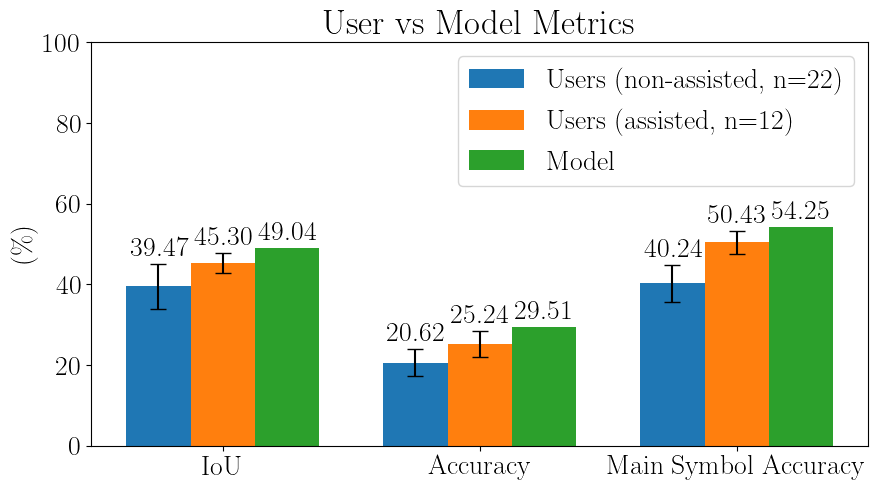

Saved to BGR/figures/user_study_weighted.pdf
Users considered: non-assisted=22, assisted=12
Weight by annotation count: True


In [71]:
# Model metrics (percent)
# model_ious = 49.91
# model_full_acc = 45.7
# model_main_acc = 69.88

plot_statistics(True, export_path="BGR/figures/user_study_weighted.pdf")

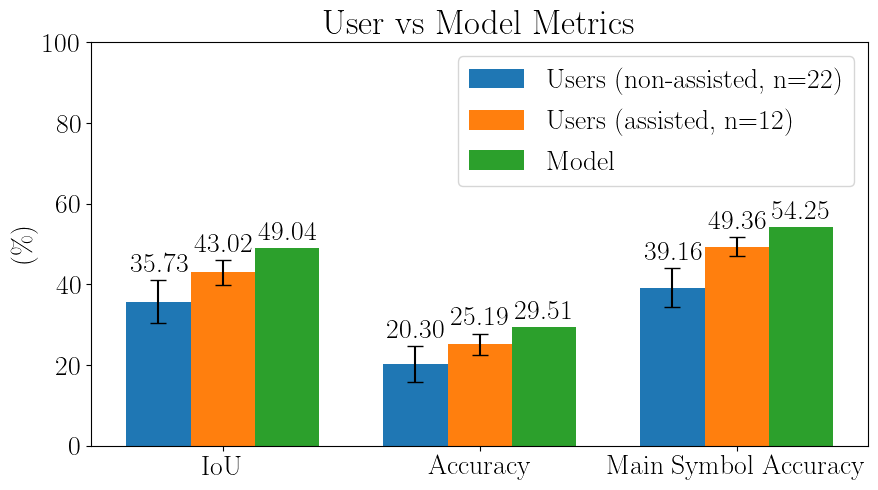

Users considered: non-assisted=22, assisted=12
Weight by annotation count: False


In [72]:
# Model metrics (percent)
# model_ious = 49.91
# model_full_acc = 45.7
# model_main_acc = 69.88

plot_statistics(False)

In [28]:
# Count number of annotations
print("Number of total annotations (non-skipped):",len(df[df["skipped"] == False]))
print("Number of total annotations non-AI (non-skipped):",len(df_non_assisted))
print("Number of total annotations AI (non-skipped):",len(df_assisted))

# Count number of images
print("Number of total images (non-skipped):", len(df[df["skipped"] == False]["image_name"].unique()))
print("Number of total images non-AI (non-skipped):", len(df_non_assisted["image_name"].unique()))
print("Number of total images AI (non-skipped):", len(df_assisted["image_name"].unique()))

# Count number of intersections in image_names
print("Number of intersections in image names:", len(np.intersect1d(df_non_assisted["image_name"].unique(), df_assisted["image_name"].unique())))

Number of total annotations (non-skipped): 257
Number of total annotations non-AI (non-skipped): 172
Number of total annotations AI (non-skipped): 85
Number of total images (non-skipped): 86
Number of total images non-AI (non-skipped): 63
Number of total images AI (non-skipped): 45
Number of intersections in image names: 22


In [ ]:
# Count number of total horizons
print("Number of total (true) horizons:", sum(df[df["skipped"] == False]["true_symbols"].apply(len)))
print("Number of total annotated horizons:", sum(df_merged[(df_merged["skipped"] == False)]["user_symbols"].apply(len)))

print("Number of total annotated horizons (non-AI):", sum(df_merged[(df_merged["skipped"] == False) & (df_merged["ml_assisted"] == False)]["user_symbols"].apply(len)))
print("Number of total annotated horizons (AI):", sum(df_merged[(df_merged["skipped"] == False) & (df_merged["ml_assisted"] == True)]["user_symbols"].apply(len)))

Number of total (true) horizons: 1049
Number of total annotated horizons: 1075
Number of total annotated horizons (non-AI): 695
Number of total annotated horizons (AI): 380


In [84]:
# Count number of users
print("Number of total unique annotators (according to anonId):", df[df["skipped"] == False]["anonId"].nunique())

print("Number of total unique annotators (non-AI):", df_non_assisted["anonId"].nunique())
print("Number of total unique annotators (AI): ", df_assisted["anonId"].nunique())

print("Number of total annotators in both phases:", len(set(df_non_assisted["anonId"]).intersection(set(df_assisted["anonId"]))))

Number of total unique annotators (according to anonId): 30
Number of total unique annotators (non-AI): 22
Number of total unique annotators (AI):  12
Number of total annotators in both phases: 4
